In [ ]:
from google.colab import files
uploaded=files.upload()

Saving BankNote_Authentication.csv to BankNote_Authentication (1).csv


Saving BankNote_Authentication.csv to BankNote_Authentication (2).csv


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
data=pd.read_csv("BankNote_Authentication.csv")
df=pd.DataFrame(data)
df.head(5)



,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [ ]:
df.isnull().sum()

,0
variance,0
skewness,0
curtosis,0
entropy,0
class,0


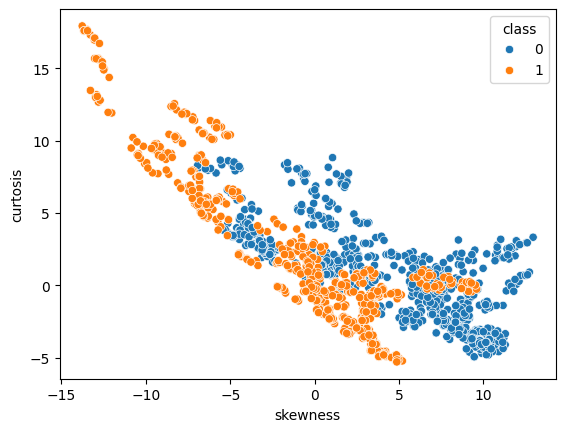

In [ ]:
sns.scatterplot(data=df,x='skewness',y='curtosis',hue='class')
plt.show()

In [ ]:
x=df.iloc[:,:-1]
y=df['class']


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

In [ ]:
from sklearn.svm import SVC
SV=SVC(kernel='rbf')
SV.fit(x_train,y_train)

SVC()

In [ ]:
print(SV.score(x_train,y_train)*100,SV.score(x_test,y_test)*100)

100.0 100.0


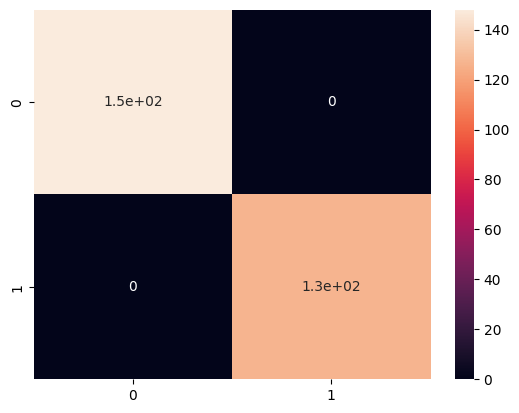

In [ ]:
from sklearn.metrics import confusion_matrix
y_pred=SV.predict(x_test)
cf=confusion_matrix(y_test,y_pred)
sns.heatmap(cf,annot=True)
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score,recall_score,precision_score,f1_score
print(accuracy_score(y_test,y_pred)*100)
print(recall_score(y_test,y_pred)*100)
print(precision_score(y_test,y_pred)*100)
print(f1_score(y_test,y_pred)*100)

100.0
100.0
100.0
100.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   variance  1372 non-null   float64
 1   skewness  1372 non-null   float64
 2   curtosis  1372 non-null   float64
 3   entropy   1372 non-null   float64
 4   class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB


In [ ]:
import numpy as np
var=float(input("Enter the value of variance: "))
skewness=float(input("Enter the value of skewness: "))
curtosis=float(input("Enter the value of curtosis: "))
entropy=float(input("Enter the value of entropy:"))
model=np.array([[var,skewness,curtosis,entropy]])
model=sc.transform(model)
Prediction=SV.predict(model)
print("The prediction is:")
if Prediction[0]==0 :

  print("This is false note")
else:
  print("This is real note")

Enter the value of variance: 2.3
Enter the value of skewness: 6.5
Enter the value of curtosis: -1.2
Enter the value of entropy:-0.8
The prediction is:
This is false note


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
